In [2]:
import pandas as pd

df = pd.read_csv('german_credit_data.csv')

df.head()


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [4]:
df = df.drop(columns=['Unnamed: 0'])

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [5]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [6]:
df['Purpose'].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [7]:
df['Saving accounts'].value_counts(dropna=False)

Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [8]:

df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

In [9]:
# the average loan amount for each purpose in descending order
df.groupby('Purpose')['Credit amount'].mean().sort_values(ascending=False)

Purpose
vacation/others        8209.333333
business               4158.041237
car                    3768.192878
furniture/equipment    3066.988950
education              2879.203390
repairs                2728.090909
radio/TV               2487.653571
domestic appliances    1498.000000
Name: Credit amount, dtype: float64

In [10]:
df.groupby('Housing')['Credit amount'].mean()

Housing
free    4906.212963
own     3060.939691
rent    3122.553073
Name: Credit amount, dtype: float64

In [11]:
age_buckets = pd.cut(df['Age'], bins=[0, 25, 35, 50, 100], labels=['Under 25', '25-35', '35-50', '50+'])
df.groupby(age_buckets)['Credit amount'].mean()

C:\Users\soita\AppData\Local\Temp\ipykernel_12640\4179234712.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(age_buckets)['Credit amount'].mean()


Age
Under 25    3003.357895
25-35       3298.690955
35-50       3395.404682
50+         3296.592920
Name: Credit amount, dtype: float64

In [12]:
from sklearn.preprocessing import StandardScaler

# Isolate the numeric columns we want to use for grouping
numeric_features = ['Age', 'Credit amount', 'Duration']
X = df[numeric_features]

# Scale the features so they all share the same mathematical weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# View the newly scaled data matrix
X_scaled[:5]

array([[ 2.76645648, -0.74513141, -1.23647786],
       [-1.19140394,  0.94981679,  2.24819436],
       [ 1.18331231, -0.41656241, -0.73866754],
       [ 0.8315025 ,  1.63424694,  1.75038404],
       [ 1.53512213,  0.5666635 ,  0.25695309]])

In [13]:
from sklearn.cluster import KMeans

# Make the K-Means model to look for 3 distinct groups
kmeans = KMeans(n_clusters=3, random_state=42)

# Run the algorithm and assign each person to a cluster (0, 1, or 2)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Count how many applicants landed in each cluster
df['Cluster'].value_counts()

Cluster
2    587
1    224
0    189
Name: count, dtype: int64

In [14]:
# averages for each cluster
df.groupby('Cluster')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Cluster,,,
0,34.756614,7609.634921,39.275132
1,51.651786,2398.473214,15.848214
2,29.654174,2207.459966,16.916525


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

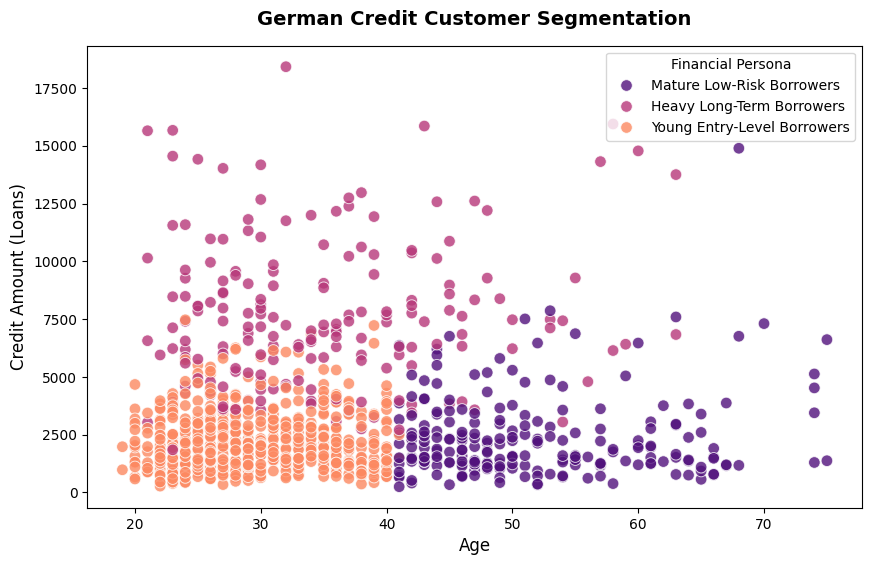

In [15]:
# Map the clusters to descriptive names inside the dataframe
cluster_names = {
    0: 'Heavy Long-Term Borrowers',
    1: 'Mature Low-Risk Borrowers',
    2: 'Young Entry-Level Borrowers'
}
df['Financial Persona'] = df['Cluster'].map(cluster_names)

# Re-plot using the new text column as the hue
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Credit amount', 
    hue='Financial Persona',  
    palette='magma', 
    alpha=0.8, 
    s=70
)

# Clean up the titles and labels cleanly 
plt.title('German Credit Customer Segmentation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Credit Amount (Loans)', fontsize=12)

plt.show()

In [16]:
# My new CSV file
df.to_csv('german_credit_segmented.csv', index=False)

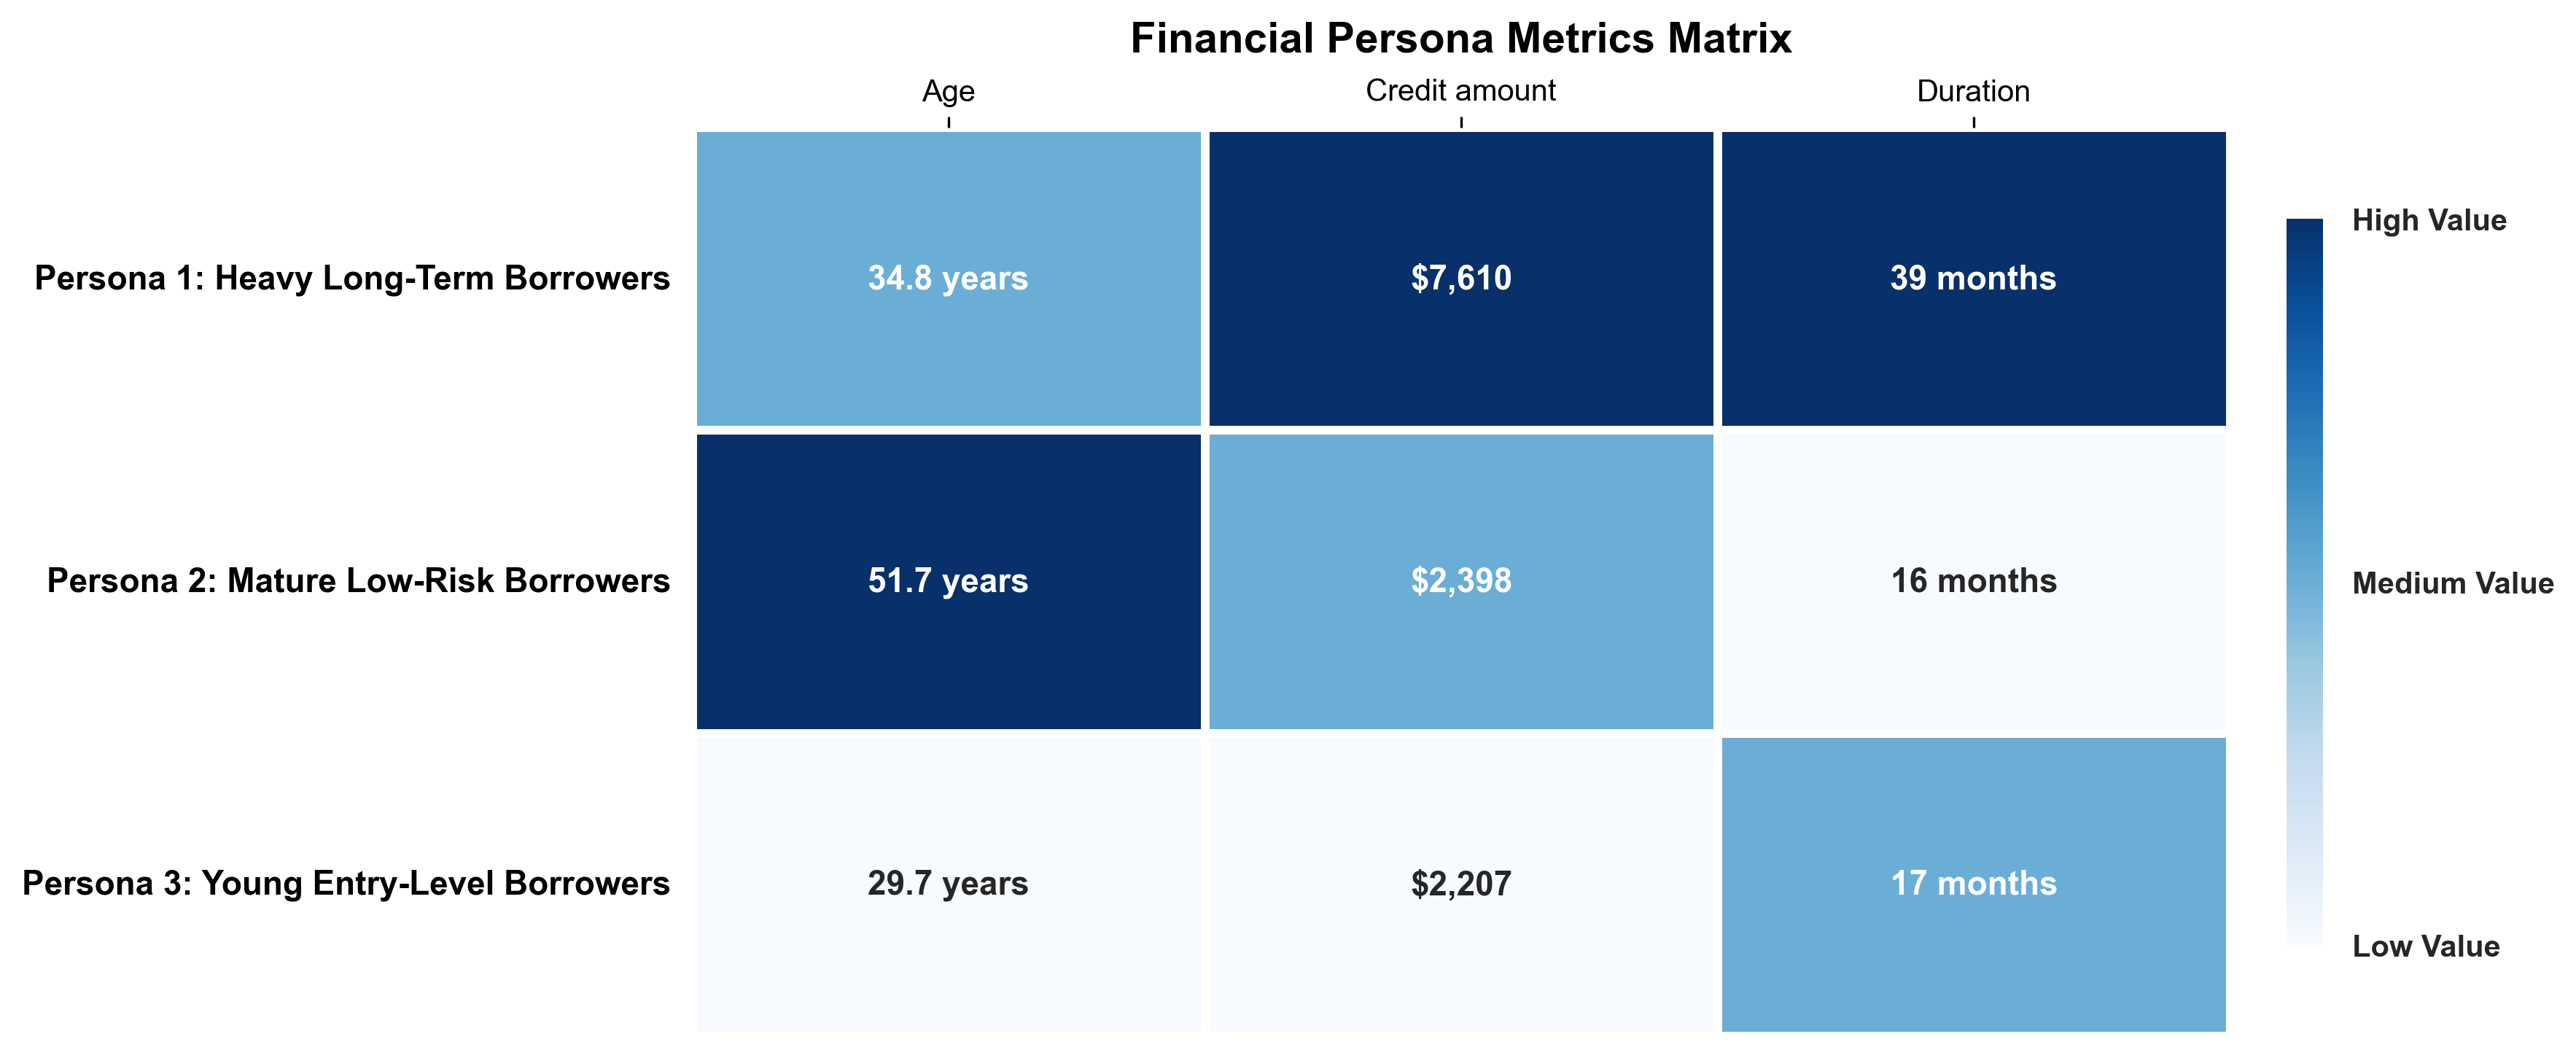

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute mean values and assign descriptive business personas
matrix = df.groupby('Cluster')[['Age', 'Credit amount', 'Duration']].mean()
matrix.index = [
    'Persona 1: Heavy Long-Term Borrowers', 
    'Persona 2: Mature Low-Risk Borrowers', 
    'Persona 3: Young Entry-Level Borrowers'
]

# Derive numerical ranks within each column strictly to govern the color distribution
matrix_rank = matrix.rank(axis=0)

# Build a beautifully formatted text matrix for executive-level presentation
labels = np.array([
    [f"{matrix.iloc[r, 0]:.1f} years", f"${matrix.iloc[r, 1]:,.0f}", f"{matrix.iloc[r, 2]:.0f} months"]
    for r in range(3)
])

# Initialize a clean, high-resolution plotting canvas (adjusted width for colorbar)
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
sns.set_theme(style="white")

# Define the colorbar parameters to show a clear scale
cbar_kws = {
    "ticks": [1, 2, 3],
    "shrink": 0.8,
    "pad": 0.03
}

# Render the heatmap using rank-driven shades and display the formatted labels
sns.heatmap(
    matrix_rank, 
    annot=labels, 
    cmap="Blues", 
    fmt="", 
    cbar=True, 
    cbar_kws=cbar_kws,
    linewidths=2.5, 
    linecolor="white",
    annot_kws={"size": 11, "weight": "bold", "fontfamily": "sans-serif"},
    ax=ax
)

# Format the colorbar scale to read logically as Low, Medium, High
cbar = ax.collections[0].colorbar
cbar.ax.set_yticklabels(['Low Value', 'Medium Value', 'High Value'], fontsize=10, weight="semibold")
cbar.ax.tick_params(left=False, right=False)

# Strip out technical chart tick lines to make the asset look like a pristine table
ax.tick_params(top=False, bottom=False, left=False, right=False)

# Optimize the typographical alignment and layout 
plt.title("Financial Persona Metrics Matrix", fontsize=14, pad=25, weight="bold", fontfamily="sans-serif")
plt.xticks(fontsize=11, weight="semibold", fontfamily="sans-serif")
plt.yticks(rotation=0, fontsize=11, weight="semibold", fontfamily="sans-serif")
ax.xaxis.tick_top() 

# Save the polished graphic
plt.tight_layout()
plt.savefig("metrics_matrix.png", bbox_inches="tight")
plt.show()

In [18]:
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Note: Replace 'X_scaled' with the actual variable name of your scaled features array
# and ensure df['Cluster'] matches your final cluster labels column

# Calculate the validation scores
sil = silhouette_score(X_scaled, df['Cluster'])
db = davies_bouldin_score(X_scaled, df['Cluster'])
ch = calinski_harabasz_score(X_scaled, df['Cluster'])

# Construct the formal evaluation matrix DataFrame
eval_matrix = pd.DataFrame({
    'Clustering Performance Metric': [
        'Silhouette Coefficient', 
        'Davies-Bouldin Index', 
        'Calinski-Harabasz Index'
    ],
    'Calculated Score': [sil, db, ch],
    'Mathematical Target': [
        'Closer to +1 (Indicates distinct, well-separated boundaries)', 
        'Lower value closer to 0 (Indicates tighter, sharper clusters)', 
        'Higher value (Indicates highly dense and well-isolated groups)'
    ]
})

# Display the polished validation matrix
print("==============================================================")
print("               REPOSSESSORY EVALUATION MATRIX                 ")
print("==============================================================")
print(eval_matrix.to_string(index=False))

               REPOSSESSORY EVALUATION MATRIX                 
Clustering Performance Metric  Calculated Score                                            Mathematical Target
       Silhouette Coefficient          0.389424   Closer to +1 (Indicates distinct, well-separated boundaries)
         Davies-Bouldin Index          0.940268  Lower value closer to 0 (Indicates tighter, sharper clusters)
      Calinski-Harabasz Index        654.158786 Higher value (Indicates highly dense and well-isolated groups)
